<a href="https://colab.research.google.com/github/A-J-Jovia/jovia-codeboosters-2026/blob/main/day5/Miniproj_day5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [44]:
import requests
import pandas as pd
import matplotlib.pyplot as plt

API_KEY = '935e9b217b5e910f452f90899b8912fe'
BASE_URL = 'https://api.openweathermap.org/data/2.5/weather'
CITIES = [
    'Mumbai', 'Tirupur', 'Bangalore', 'Chennai', 'Hyderabad', 'Kolkata',
    'Coimbatore', 'Jaipur', 'Tirunelveli', 'Trichy', 'Sivakasi', 'Madurai',
    'Dindigul', 'Karur', 'Salem', 'Vellore',
    'Delhi', 'Pune', 'Nagpur', 'Surat', 'Ahmedabad', 'Lucknow', 'Kanpur',
    'Patna', 'Bhopal', 'Indore', 'Vadodara', 'Rajkot', 'Nashik', 'Aurangabad',
    'Amritsar', 'Ludhiana', 'Jalandhar', 'Agra', 'Varanasi', 'Allahabad',
    'Meerut', 'Ghaziabad', 'Noida', 'Faridabad', 'Gurgaon', 'Chandigarh',
    'Shimla', 'Dehradun', 'Ranchi', 'Jamshedpur', 'Bhubaneswar', 'Cuttack',
    'Guwahati', 'Shillong', 'Imphal', 'Aizawl', 'Kohima', 'Gangtok',
    'Pondicherry', 'Thoothukudi', 'Erode', 'Palakkad', 'Thrissur', 'Kochi',
    'Thiruvananthapuram', 'Kozhikode', 'Mangalore', 'Udupi', 'Belgaum',
    'Hubli', 'Dharwad', 'Mysore', 'Hosur', 'Nagercoil', 'Kanyakumari',
    'Tiruppur', 'Tiruvannamalai', 'Villupuram', 'Cuddalore', 'Kanchipuram',
    'Thanjavur', 'Nagapattinam', 'Pudukkottai', 'Virudhunagar',
    'Ramanathapuram', 'Namakkal', 'Krishnagiri', 'Dharmapuri', 'Ariyalur',
    'Perambalur', 'Chittoor', 'Vijayawada', 'Visakhapatnam',
    'Guntur', 'Nellore', 'Warangal', 'Karimnagar', 'Nizamabad', 'Adilabad',
    'Mahbubnagar', 'Kurnool', 'Anantapur', 'Raipur', 'Bilaspur', 'Durg',
    'Korba', 'Jabalpur', 'Satna', 'Rewa', 'Sagar', 'Ujjain', 'Hoshangabad',
    'Gwalior', 'Aligarh', 'Moradabad', 'Bareilly', 'Saharanpur', 'Roorkee',
    'Haridwar', 'Panaji', 'Mapusa',
    # International cities
    'New York', 'Los Angeles', 'Chicago', 'San Francisco', 'London',
    'Paris', 'Berlin', 'Rome', 'Madrid', 'Lisbon', 'Tokyo', 'Osaka',
    'Seoul', 'Beijing', 'Shanghai', 'Hong Kong', 'Singapore', 'Dubai',
    'Abu Dhabi', 'Doha', 'Sydney', 'Kansas City', 'Melbourne', 'Toronto', 'Vancouver',
    'Mexico City', 'Buenos Aires', 'Rio de Janeiro', 'Cape Town',
    'Johannesburg', 'Nairobi', 'Atlanta', 'Boston', 'Dallas', 'Houston',
    'Phoenix', 'San Antonio', 'San Diego', 'Philadelphia',
    'San Jose', 'Austin', 'Jacksonville',
    'Fort Worth', 'Charlotte', 'Indianapolis', 'Seattle',
    'Denver', 'Washington', 'Detroit', 'El Paso', 'Memphis', 'Nashville',
    'Oklahoma City', 'Louisville', 'Milwaukee', 'Baltimore', 'Albuquerque',
    'Tucson', 'Fresno', 'Sacramento', 'Mesa', 'Omaha',
    'Colorado Springs', 'Raleigh', 'Miami', 'Long Beach', 'Virginia Beach',
    'Oakland', 'Minneapolis', 'Tulsa', 'Arlington', 'New Orleans',
    'Wichita', 'Cleveland', 'Tampa', 'Bakersfield', 'Aurora', 'Anaheim',
    'Honolulu', 'Santa Ana', 'Riverside', 'Corpus Christi', 'Lexington',
    'Stockton', 'Henderson', 'Saint Paul', 'St. Louis', 'Cincinnati',
    'Pittsburgh', 'Greensboro', 'Anchorage', 'Plano', 'Lincoln',
    'Orlando', 'Irvine', 'Newark', 'Durham', 'Chula Vista', 'Toledo',
    'Fort Wayne', 'St. Petersburg', 'Laredo', 'Jersey City', 'Chandler',
    'Madison', 'Lubbock', 'Scottsdale', 'Reno', 'Buffalo', 'Gilbert',
    'Glendale', 'North Las Vegas', 'Winston-Salem', 'Norfolk', 'Chesapeake',
    'Garland', 'Irving', 'Hialeah', 'Fremont', 'Boise', 'Richmond',
    'Baton Rouge', 'Spokane', 'Des Moines', 'Tacoma', 'San Bernardino',
    'Modesto', 'Fontana', 'Oxnard', 'Moreno Valley', 'Fayetteville',
    'Huntington Beach', 'Yonkers', 'Montgomery', 'Amarillo', 'Little Rock',
    'Akron', 'Columbus', 'Augusta', 'Grand Rapids', 'Salt Lake City',
    'Tallahassee', 'Overland Park', 'Knoxville', 'Worcester', 'Brownsville',
    'Tempe', 'Santa Clarita', 'Shreveport', 'Mobile', 'Newport News',
    'Cape Coral', 'Peoria', 'Sioux Falls', 'Springfield', 'Pembroke Pines',
    'Evansville', 'Savannah', 'Dayton', 'Clarksville', 'Palmdale',
    'Salinas', 'Pasadena', 'Macon', 'Pomona',
    'Alexandria', 'Lakewood', 'Sunnyvale', 'Escondido',
    'Hollywood', 'Bridgeport', 'Paterson', 'Naperville', 'Rockford',
    'Torrance', 'Joliet', 'Bellevue', 'Midland', 'Denton', 'Roseville',
    'Thornton', 'Miramar', 'Mesquite', 'Olathe',
    'Carrollton', 'Waco', 'Sterling Heights', 'West Valley City',
    'Columbia', 'Kansas City', 'Elk Grove', 'Garden Grove'
]

print(f"API configured for {len(CITIES)} cities")
print(f"Cities: {CITIES}")


API configured for 309 cities
Cities: ['Mumbai', 'Tirupur', 'Bangalore', 'Chennai', 'Hyderabad', 'Kolkata', 'Coimbatore', 'Jaipur', 'Tirunelveli', 'Trichy', 'Sivakasi', 'Madurai', 'Dindigul', 'Karur', 'Salem', 'Vellore', 'Delhi', 'Pune', 'Nagpur', 'Surat', 'Ahmedabad', 'Lucknow', 'Kanpur', 'Patna', 'Bhopal', 'Indore', 'Vadodara', 'Rajkot', 'Nashik', 'Aurangabad', 'Amritsar', 'Ludhiana', 'Jalandhar', 'Agra', 'Varanasi', 'Allahabad', 'Meerut', 'Ghaziabad', 'Noida', 'Faridabad', 'Gurgaon', 'Chandigarh', 'Shimla', 'Dehradun', 'Ranchi', 'Jamshedpur', 'Bhubaneswar', 'Cuttack', 'Guwahati', 'Shillong', 'Imphal', 'Aizawl', 'Kohima', 'Gangtok', 'Pondicherry', 'Thoothukudi', 'Erode', 'Palakkad', 'Thrissur', 'Kochi', 'Thiruvananthapuram', 'Kozhikode', 'Mangalore', 'Udupi', 'Belgaum', 'Hubli', 'Dharwad', 'Mysore', 'Hosur', 'Nagercoil', 'Kanyakumari', 'Tiruppur', 'Tiruvannamalai', 'Villupuram', 'Cuddalore', 'Kanchipuram', 'Thanjavur', 'Nagapattinam', 'Pudukkottai', 'Virudhunagar', 'Ramanathapuram', 

In [45]:
def fetch_weather(city, api_key):
    params = {
        'q': city,
        'appid': api_key,
        'units': 'metric'
    }

    try:
        response = requests.get(BASE_URL, params=params, timeout=10)
        response.raise_for_status()
        data = response.json()
        main = data.get('main', {})
        wind = data.get('wind', {})
        weather = data.get('weather', [{}])

        return {
            'city': city,
            'temperature': round(main.get('temp', 0), 1),
            'feels_like': round(main.get('feels_like', 0), 1),
            'humidity': main.get('humidity', 0),
            'pressure': main.get('pressure', 0),
            'wind_speed': wind.get('speed', 0),
            'condition': weather[0].get('description', '').title(),
            'visibility': data.get('visibility', 0)
        }

    except requests.exceptions.HTTPError:
        try:
            err = response.json().get('message', 'Unknown Error')
        except Exception:
            err = 'Unknown Error'
        print(f"ERROR {response.status_code} for {city}: {err}")
    except requests.exceptions.ConnectionError:
        print(f"CONNECTION ERROR for {city} - check internet connection")
    except requests.exceptions.Timeout:
        print(f"TIMEOUT for {city} - API did not respond in 10 seconds")
    except Exception as e:
        print(f"UNEXPECTED ERROR for {city}: {e}")

    return None

print("="*60)
print("[1] GETTING WEATHER DATA THROUGH API IN OpenWeatherMap.org")
print("="*60,"\n")
print('Calling Weather API...')
weather_records =[]

for city in CITIES:
    print(f" Fetching: {city}...", end='')
    record = fetch_weather(city, API_KEY)
    if record:
      weather_records.append(record)
      print(f" {record["temperature"]}°C, {record["condition"]}")
    else:
      print("FAILED")

print(f"\nSuccessfully fetched: {len(weather_records)}/{len(CITIES)} cities")
print(f"\nSuccessfully fetched: {len(weather_records)}/{len(CITIES)} cities")

[1] GETTING WEATHER DATA THROUGH API IN OpenWeatherMap.org

Calling Weather API...
 Fetching: Mumbai... 34.0°C, Smoke
 Fetching: Tirupur... 34.5°C, Overcast Clouds
 Fetching: Bangalore... 31.3°C, Scattered Clouds
 Fetching: Chennai... 34.7°C, Scattered Clouds
 Fetching: Hyderabad... 38.2°C, Scattered Clouds
 Fetching: Kolkata... 32.0°C, Haze
 Fetching: Coimbatore... 33.9°C, Few Clouds
 Fetching: Jaipur... 35.6°C, Haze
 Fetching: Tirunelveli... 35.1°C, Overcast Clouds
 Fetching: Trichy... 40.0°C, Few Clouds
 Fetching: Sivakasi... 37.1°C, Overcast Clouds
 Fetching: Madurai... 38.0°C, Scattered Clouds
 Fetching: Dindigul... 36.5°C, Broken Clouds
 Fetching: Karur... 37.6°C, Broken Clouds
 Fetching: Salem... 37.0°C, Scattered Clouds
 Fetching: Vellore... 34.1°C, Broken Clouds
 Fetching: Delhi... 35.0°C, Scattered Clouds
 Fetching: Pune... 35.8°C, Clear Sky
 Fetching: Nagpur... 40.0°C, Haze
 Fetching: Surat... 34.0°C, Few Clouds
 Fetching: Ahmedabad... 36.0°C, Dust
 Fetching: Lucknow... 33.0

In [46]:
df = pd.DataFrame(weather_records)
df.head(30)

,city,temperature,feels_like,humidity,pressure,wind_speed,condition,visibility
0,Mumbai,34.0,41.0,59,1008,5.66,Smoke,5000
1,Tirupur,34.5,37.9,45,1007,8.18,Overcast Clouds,10000
2,Bangalore,31.3,34.2,55,1008,4.12,Scattered Clouds,8000
3,Chennai,34.7,41.7,56,1004,3.09,Scattered Clouds,6000
4,Hyderabad,38.2,38.9,27,1008,6.17,Scattered Clouds,6000
5,Kolkata,32.0,39.0,70,1001,3.09,Haze,3500
6,Coimbatore,33.9,36.9,46,1008,5.14,Few Clouds,7000
7,Jaipur,35.6,35.6,30,1005,4.63,Haze,5000
8,Tirunelveli,35.1,38.8,44,1006,7.46,Overcast Clouds,10000
9,Trichy,40.0,47.0,44,1005,2.57,Few Clouds,6000


In [47]:
print("="*60)
print("[2] DATA CLEANING")
print("="*60,"\n")

print("\n[1] MISSING VALUES per columns:")
print(df.isnull().sum())

print(f"\n[2] DUPLICATE ROWS: {df.duplicated().sum()}")

print("\n[3] DATA TYPE")
print(df.dtypes)

print("\n[4] RANGE OF DATA (for numerical columns)")
for col in df.select_dtypes(include=['number']).columns:
    print(f"{col}: Min={df[col].min()}, Max={df[col].max()}")

print("\n[5] UNIQUE CONDITIONS:")
print(df['condition'].unique())

print("\n[6] Sample cities:")
print(df['city'].unique()[:8])


[2] DATA CLEANING


[1] MISSING VALUES per columns:
city           0
temperature    0
feels_like     0
humidity       0
pressure       0
wind_speed     0
condition      0
visibility     0
dtype: int64

[2] DUPLICATE ROWS: 1

[3] DATA TYPE
city            object
temperature    float64
feels_like     float64
humidity         int64
pressure         int64
wind_speed     float64
condition       object
visibility       int64
dtype: object

[4] RANGE OF DATA (for numerical columns)
temperature: Min=6.8, Max=43.0
feels_like: Min=3.9, Max=47.3
humidity: Min=11, Max=99
pressure: Min=998, Max=1024
wind_speed: Min=0.0, Max=10.94
visibility: Min=402, Max=10000

[5] UNIQUE CONDITIONS:
['Smoke' 'Overcast Clouds' 'Scattered Clouds' 'Haze' 'Few Clouds'
 'Broken Clouds' 'Clear Sky' 'Dust' 'Mist' 'Thunderstorm' 'Light Rain'
 'Fog' 'Heavy Intensity Rain' 'Moderate Rain']

[6] Sample cities:
['Mumbai' 'Tirupur' 'Bangalore' 'Chennai' 'Hyderabad' 'Kolkata'
 'Coimbatore' 'Jaipur']


In [48]:
cleaned_df = df.copy()
print(f"WORKING COPY CREATED: {cleaned_df.shape}")

WORKING COPY CREATED: (309, 8)


In [49]:
print("Before fixing nulls:", cleaned_df.isnull().sum().sum(),"total missing values")
if (cleaned_df['condition'] == '').any():
    cleaned_df['condition'].replace('', 'Unknown Condition', inplace=True)
    print("Filled empty 'condition' with 'Unknown Condition'")
print("After fixing nulls:", cleaned_df.isnull().sum().sum(),"total missing values")

Before fixing nulls: 0 total missing values
After fixing nulls: 0 total missing values


In [50]:
len_before = len(cleaned_df)
print(f'Before deduplication: {len(cleaned_df)} rows')
print(f'Duplicate rows: {cleaned_df.duplicated().sum()}')

if cleaned_df.duplicated().sum() > 0:
    print('\nDuplicate rows (first 6 if any):')
    print(cleaned_df[cleaned_df.duplicated(keep=False)][['city', 'temperature', 'condition']].head(6))
    cleaned_df.drop_duplicates(inplace=True)
    len_after = len(cleaned_df)
    print(f'\nAfter deduplication: {len(cleaned_df)} rows')
    print(f'Rows removed: {len_before - len_after}')
else:
    print('\nNo duplicate rows found.')

display(cleaned_df.head())

Before deduplication: 309 rows
Duplicate rows: 1

Duplicate rows (first 6 if any):
            city  temperature        condition
138  Kansas City         21.2  Overcast Clouds
306  Kansas City         21.2  Overcast Clouds

After deduplication: 308 rows
Rows removed: 1


,city,temperature,feels_like,humidity,pressure,wind_speed,condition,visibility
0,Mumbai,34.0,41.0,59,1008,5.66,Smoke,5000
1,Tirupur,34.5,37.9,45,1007,8.18,Overcast Clouds,10000
2,Bangalore,31.3,34.2,55,1008,4.12,Scattered Clouds,8000
3,Chennai,34.7,41.7,56,1004,3.09,Scattered Clouds,6000
4,Hyderabad,38.2,38.9,27,1008,6.17,Scattered Clouds,6000


In [51]:
print("="*60)
print("[3] SQLlite Storage")
print("="*60,"\n")

import sqlite3

# Create a connection to an SQLite database file
conn = sqlite3.connect('weather_data.db')

# Save the cleaned DataFrame to an SQL table
# if_exists='replace' will overwrite the table if it already exists
cleaned_df.to_sql('weather_data', conn, if_exists='replace', index=False)

# Close the database connection
conn.close()

print("Cleaned weather data has been successfully stored in 'weather_data.db' in the table 'weather_data'.")

[3] SQLlite Storage

Cleaned weather data has been successfully stored in 'weather_data.db' in the table 'weather_data'.


/tmp/ipykernel_4223/3002828604.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab20', len(conditions))


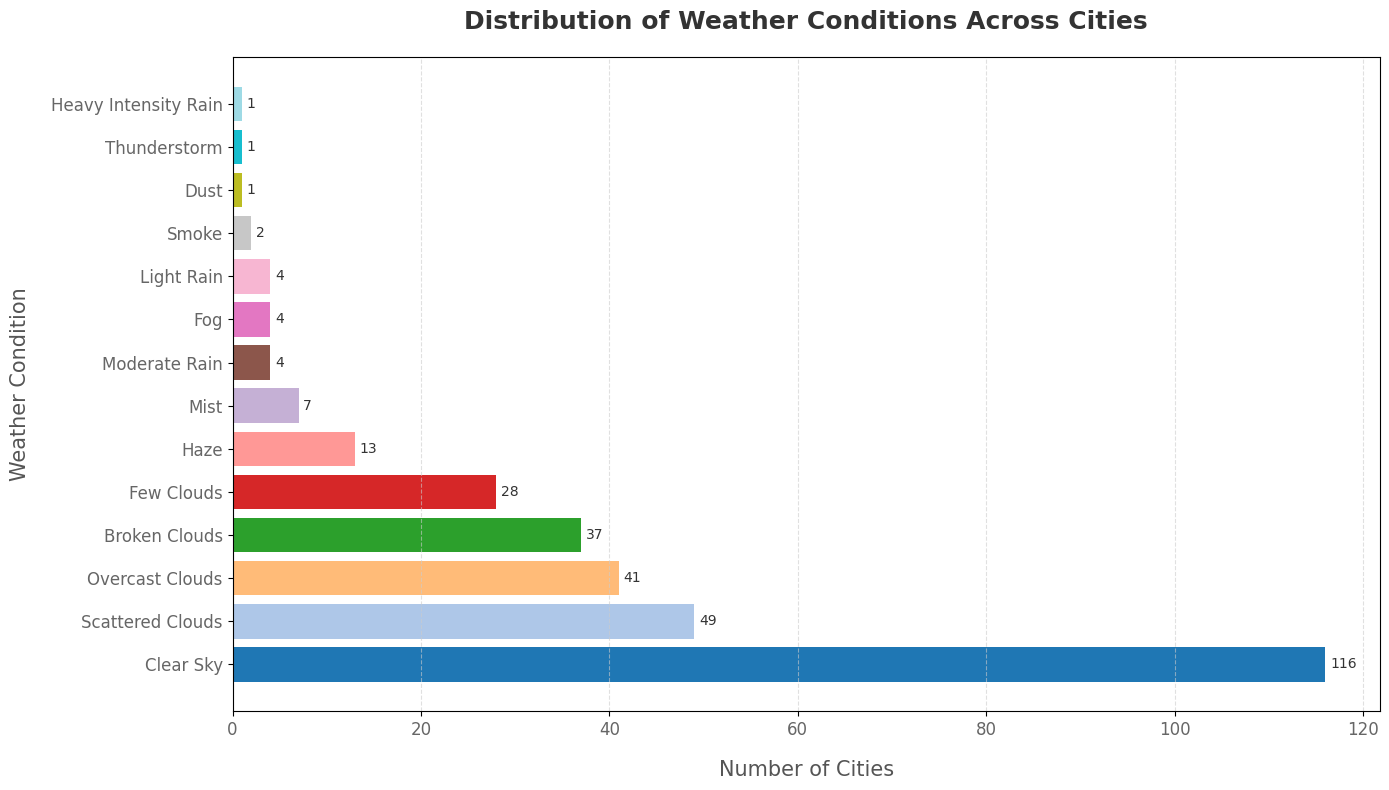

In [52]:
import matplotlib.pyplot as plt

# Count the occurrences of each weather condition
condition_counts = cleaned_df['condition'].value_counts()

# Prepare data for plotting
conditions = condition_counts.index
counts = condition_counts.values

# Generate a list of distinct colors for each bar
# Using a colormap for variety. You can choose different colormaps like 'tab10', 'viridis', 'plasma', etc.
colors = plt.cm.get_cmap('tab20', len(conditions))

plt.figure(figsize=(14, 8))
plt.barh(conditions, counts, color=colors(range(len(conditions))))

plt.title('Distribution of Weather Conditions Across Cities',
          fontsize=18, fontweight='bold', color='#333333', pad=20)
plt.xlabel('Number of Cities',
           fontsize=15, color='#555555', labelpad=15)
plt.ylabel('Weather Condition',
           fontsize=15, color='#555555', labelpad=15)

plt.xticks(fontsize=12, color='#666666')
plt.yticks(fontsize=12, color='#666666')

# Add grid for readability
plt.grid(axis='x', linestyle='--', alpha=0.6, color='#CCCCCC')

# Invert y-axis to have the highest count at the top if desired, or keep as is
# plt.gca().invert_yaxis()

# Add value labels on the bars for clarity
for index, value in enumerate(counts):
    plt.text(value + 0.5, index, str(value), color='#333333', va='center', fontsize=10)

plt.tight_layout()
plt.show()

/tmp/ipykernel_4223/2498842383.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('Paired', len(labels)) # Using 'Paired' colormap for distinct colors


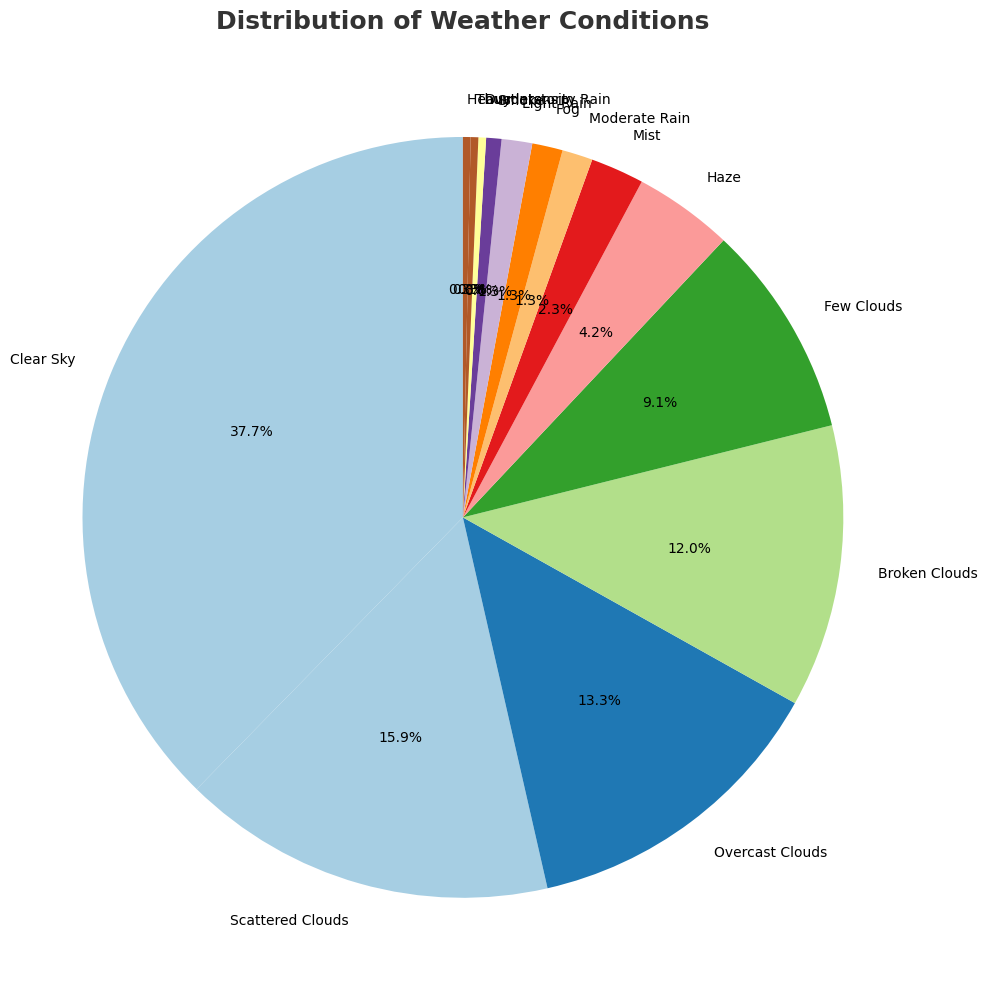

In [53]:
condition_counts = cleaned_df['condition'].value_counts()
labels = condition_counts.index
sizes = condition_counts.values

# Generate colors for the pie chart
colors = plt.cm.get_cmap('Paired', len(labels)) # Using 'Paired' colormap for distinct colors

plt.figure(figsize=(10, 10))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90, colors=colors(range(len(labels))))
plt.title('Distribution of Weather Conditions',
          fontsize=18, fontweight='bold', color='#333333', pad=20)
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.tight_layout()
plt.show()

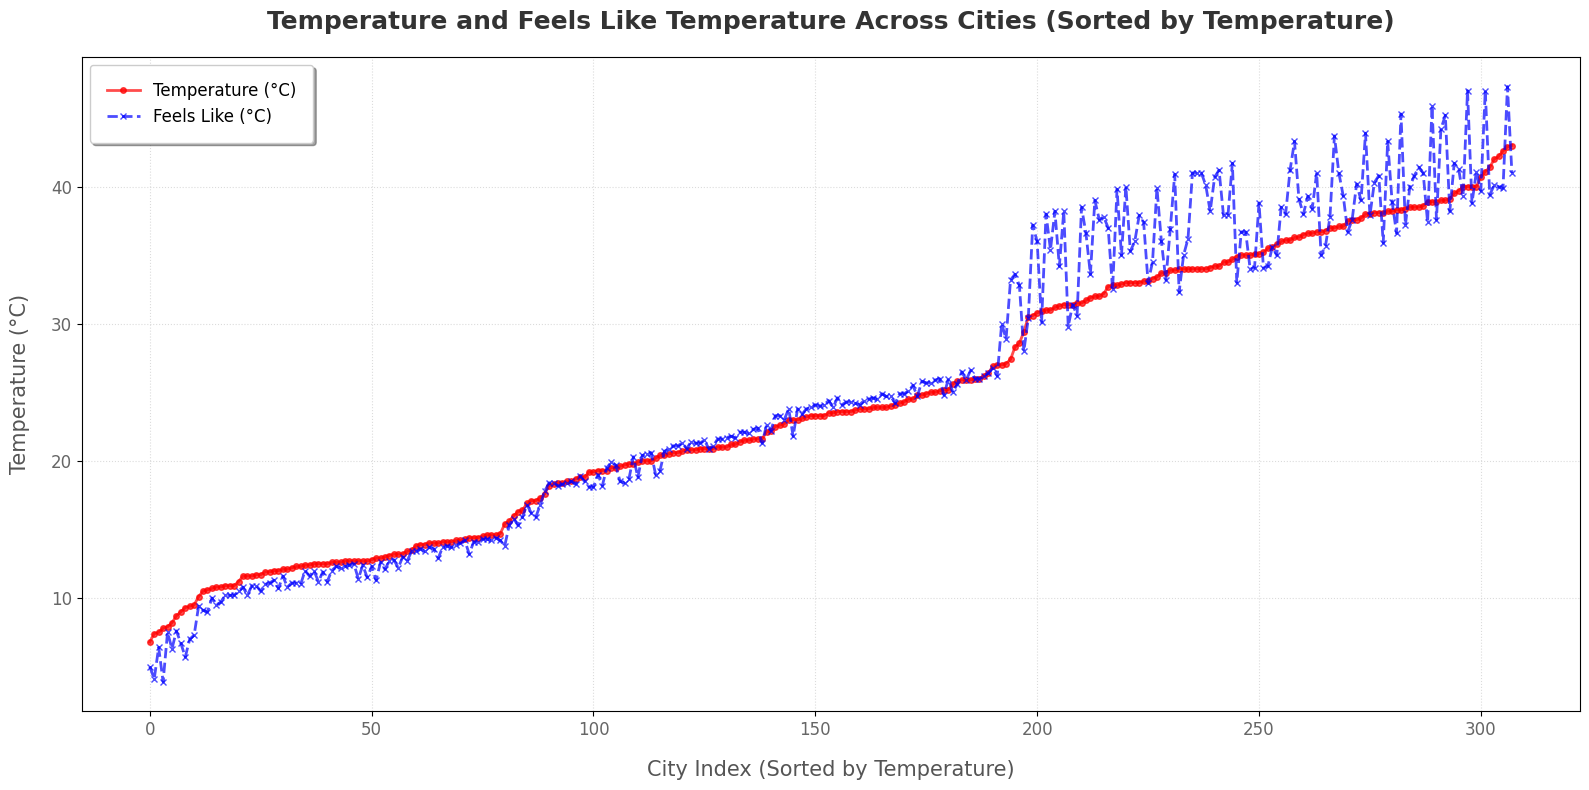

In [54]:
import matplotlib.pyplot as plt

# Sort the DataFrame by temperature for a meaningful trend on the line chart
sorted_df = cleaned_df.sort_values(by='temperature').reset_index(drop=True)

plt.figure(figsize=(16, 8))

# Plot actual temperature
plt.plot(sorted_df.index, sorted_df['temperature'], label='Temperature (°C)',
         color='red', marker='o', linestyle='-', linewidth=2, markersize=4, alpha=0.7)

# Plot 'feels like' temperature
plt.plot(sorted_df.index, sorted_df['feels_like'], label='Feels Like (°C)',
         color='blue', marker='x', linestyle='--', linewidth=2, markersize=4, alpha=0.7)

plt.title('Temperature and Feels Like Temperature Across Cities (Sorted by Temperature)',
          fontsize=18, fontweight='bold', color='#333333', pad=20)
plt.xlabel('City Index (Sorted by Temperature)',
           fontsize=15, color='#555555', labelpad=15)
plt.ylabel('Temperature (°C)',
           fontsize=15, color='#555555', labelpad=15)

plt.xticks(fontsize=12, color='#666666')
plt.yticks(fontsize=12, color='#666666')

plt.grid(True, linestyle=':', alpha=0.7, color='#CCCCCC')
plt.legend(fontsize=12, frameon=True, shadow=True, borderpad=1)

plt.tight_layout()
plt.show()

In [55]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

X = cleaned_df[['humidity', 'pressure', 'wind_speed', 'feels_like', 'visibility']]
y = cleaned_df['temperature']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

dt_model = DecisionTreeRegressor(
    max_depth=5,
    random_state=42
)

dt_model.fit(X_train_scaled, y_train)
dt_pred = dt_model.predict(X_test_scaled)

dt_mae = mean_absolute_error(y_test, dt_pred)
dt_rmse = np.sqrt(mean_squared_error(y_test, dt_pred))
dt_r2 = r2_score(y_test, dt_pred)

print("=== Model: Decision Tree Regression ===")
print(f"MAE: {dt_mae:.4f} (prediction are off by {dt_mae:.1f} points on average)")
print(f"RMSE: {dt_rmse:.4f} (error with penalty for large mistakes)")
print(f"R2 Score: {dt_r2:.4f} {dt_r2*100:.1f}% of programming score varience explained")
print()

=== Model: Decision Tree Regression ===
MAE: 0.8200 (prediction are off by 0.8 points on average)
RMSE: 1.1824 (error with penalty for large mistakes)
R2 Score: 0.9863 98.6% of programming score varience explained

